#**Data optimization**

# **Loading the cleaned dataset**

In [ ]:
import os
import time
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

folder_path = '/content/drive/MyDrive/HPDP_Project1/data'
clean_file = os.path.join(folder_path, 'cleaned_data.csv')
optimize_file = os.path.join(folder_path, 'optimize_data.csv')

print("Checking if cleaned data is available...")

if os.path.exists(clean_file):
    df_clean = pd.read_csv(clean_file)
    file_size_mb = os.path.getsize(clean_file) / (1024 * 1024)
    print(f"Success! Loaded cleaned data file.")
    print(f"Dataset Size: {df_clean.shape[0]:,} rows across {df_clean.shape[1]} columns.")
    print(f"File Size: {file_size_mb:.2f} MB")

    print("\n==============================================")
    print("CLEAN DATASET PREVIEW (FIRST 5 ROWS)")
    print("==============================================")
    display(df_clean.head(5))
    print("==============================================")
else:
    print(f"ERROR: Cannot find '{clean_file}'.")
    print("Tip: Make sure you ran 'clean_data.ipynb' and saved the output file first!")

Mounted at /content/drive
Checking if cleaned data is available...
Success! Loaded cleaned data file.
Dataset Size: 112,499 rows across 12 columns.
File Size: 29.46 MB

CLEAN DATASET PREVIEW (FIRST 5 ROWS)


,job_title,occupation_category,salary_range,contract_type,working_hours,education_level,location,job_url,vacancy_id,salary_min,salary_max,salary_average
0,Clerk Assistant,Administrative & Support Services,RM 2530 - RM 3946,Part-Time,Normal Hours,Bachelor's Degree or Equivalent,Pahang,https://myfuturejobs.gov.my/administrative-and...,132886,2530.0,3946.0,3238.0
1,Office Executive,Administrative & Support Services,RM 2791 - RM 5885,Permanent,2 Shift Time,SPM / O Level / SKM Level 1 / SKM Level 2 / SK...,Johor,https://myfuturejobs.gov.my/administrative-and...,327732,2791.0,5885.0,4338.0
2,Office Executive,Administrative & Support Services,RM 2211 - RM 6197,Internship,Normal Hours,SPM / O Level / SKM Level 1 / SKM Level 2 / SK...,Penang,https://myfuturejobs.gov.my/administrative-and...,511550,2211.0,6197.0,4204.0
3,Office Executive,Administrative & Support Services,RM 2273 - RM 6179,Permanent,2 Shift Time,SPM / O Level / SKM Level 1 / SKM Level 2 / SK...,Perak,https://myfuturejobs.gov.my/administrative-and...,366654,2273.0,6179.0,4226.0
4,Clerk Assistant,Administrative & Support Services,RM 2485 - RM 4278,Part-Time,Full-Time,SPM / O Level / SKM Level 1 / SKM Level 2 / SK...,Penang,https://myfuturejobs.gov.my/administrative-and...,768107,2485.0,4278.0,3381.5


# **System Metrics Setup (Performance Tracking)**


In [ ]:
import threading
import tracemalloc
import psutil
import time
import numpy as np

class MetricsCollector:
    """
    Context manager that records execution time, peak memory,
    CPU utilization, and throughput for a block of code.
    """
    def __init__(self, name):
        self.name = name
        self._cpu_samples = []
        self._stop_event = threading.Event()
        self._monitor_thread = None

    def _monitor_cpu(self):
        while not self._stop_event.is_set():
            self._cpu_samples.append(psutil.cpu_percent(interval=0.1))

    def __enter__(self):
        self._process = psutil.Process()
        self._mem_before = self._process.memory_info().rss / (1024 ** 2)
        tracemalloc.start()

        self._stop_event.clear()
        self._cpu_samples = []
        self._monitor_thread = threading.Thread(target=self._monitor_cpu, daemon=True)
        self._monitor_thread.start()

        self._start_time = time.perf_counter()
        return self

    def __exit__(self, *args):
        self.elapsed_time = time.perf_counter() - self._start_time
        self._stop_event.set()
        self._monitor_thread.join(timeout=1.0)

        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        mem_after = self._process.memory_info().rss / (1024 ** 2)
        self.peak_memory_mb = max(peak / (1024 ** 2), mem_after - self._mem_before)

        self.avg_cpu_pct = np.mean(self._cpu_samples) if self._cpu_samples else 0.0
        self.max_cpu_pct = max(self._cpu_samples) if self._cpu_samples else 0.0

    def throughput(self, n_rows):
        return n_rows / self.elapsed_time

print("✅ MetricsCollector successfully created to track Time, Memory, CPU, and Throughput!")

✅ MetricsCollector successfully created to track Time, Memory, CPU, and Throughput!


### **Section 1: Pandas — Baseline Processing**
The baseline uses standard pandas with no parallelism — everything runs sequentially on a single CPU core.

**Pipeline:**
1. **Load CSV** with `pd.read_csv()`
2. **Filter rows:** `salary_average > 0` and `salary_max > 0` (removes incomplete salary listings)
3. **Feature engineering:** compute `salary_gap` and `gap_percentage`
4. **Aggregate by location** — average salary, job count, average max salary, and median salary
5. **Aggregate by contract type** — average salary and job count
6. **Find top 10 highest-paying jobs** (highest average salary)

In [ ]:
import pandas as pd

# ── Step 1 to 6 inside the Function ────────────────────
def baseline_analysis(csv_path):
    # ── Step 1: Load data
    df = pd.read_csv(csv_path)
    total_rows = len(df)

    # ── Step 2: Filter (keeping rows with valid salary records)
    df_f = df[(df['salary_average'] > 0) & (df['salary_max'] > 0)].copy()

    # ── Step 3: Feature Engineering (custom calculations for job features)
    df_f['salary_gap'] = df_f['salary_max'] - df_f['salary_min']
    df_f['gap_percentage'] = (df_f['salary_gap'] / df_f['salary_min']) * 100

    # ── Step 4: Aggregate by location
    location_stats = df_f.groupby('location').agg(
        avg_salary     = ('salary_average', 'mean'),
        job_count      = ('vacancy_id',     'count'),
        avg_max_salary = ('salary_max',     'mean'),
        median_salary  = ('salary_average', 'median')
    ).reset_index().sort_values('avg_salary', ascending=False)

    # ── Step 5: Aggregate by contract type
    contract_stats = df_f.groupby('contract_type').agg(
        avg_salary    = ('salary_average', 'mean'),
        job_count     = ('vacancy_id',     'count')
    ).reset_index()

    # ── Step 6: Top 10 highest-paying jobs
    top_jobs = df_f.nlargest(10, 'salary_average')[
        ['job_title', 'location', 'salary_average', 'contract_type']
    ]

    return total_rows, len(df_f), location_stats, contract_stats, top_jobs


# ── EXECUTE AND MEASURE IMMEDIATELY (Like your friend) ──
print("=" * 60)
print("SECTION 1: BASELINE — Serial Pandas Processing")
print("=" * 60)

# Create a dictionary to log results for the final chart later
if 'results_log' not in locals():
    results_log = {}

with MetricsCollector("Baseline") as m:
    total_rows, filtered_rows, location_stats, contract_stats, top_jobs = baseline_analysis(clean_file)

# Store results for comparison later
results_log['Baseline'] = {
    'elapsed_time_s' : m.elapsed_time,
    'peak_memory_mb' : m.peak_memory_mb,
    'avg_cpu_pct'    : m.avg_cpu_pct,
    'max_cpu_pct'    : m.max_cpu_pct,
    'throughput_rps' : m.throughput(total_rows),
}

# ── Print metrics ──────────────────────────────────────────
print(f"\nTotal rows loaded   : {total_rows:,}")
print(f"Rows after filter   : {filtered_rows:,}")

print(f"\nExecution Time      : {m.elapsed_time:.3f} s")
print(f"Peak Memory         : {m.peak_memory_mb:.1f} MB")
print(f"Avg CPU Utilization : {m.avg_cpu_pct:.1f}%")
print(f"Max CPU Utilization : {m.max_cpu_pct:.1f}%")
print(f"Throughput          : {m.throughput(total_rows):,.0f} rows/s")

# ── Display results ────────────────────────────────────────
print("\n--- Average Salary by Location (Top 10) ---")
display(location_stats.head(10))

print("\n--- Stats by Contract Type ---")
display(contract_stats)

print("\n--- Top 10 Highest Paying Jobs ---")
display(top_jobs.reset_index(drop=True))

SECTION 1: BASELINE — Serial Pandas Processing

Total rows loaded   : 112,499
Rows after filter   : 112,499

Execution Time      : 1.538 s
Peak Memory         : 62.5 MB
Avg CPU Utilization : 95.1%
Max CPU Utilization : 100.0%
Throughput          : 73,163 rows/s

--- Average Salary by Location (Top 10) ---


,location,avg_salary,job_count,avg_max_salary,median_salary
1,Kedah,3850.500743,8743,5060.670937,3840.50
8,Sabah,3848.883327,8451,5059.023784,3847.00
10,Selangor,3846.956675,8644,5059.341161,3843.00
6,Penang,3845.374569,8694,5058.937313,3841.25
5,Pahang,3844.214771,8828,5051.452990,3838.00
0,Johor,3843.549549,8648,5052.513414,3829.50
4,Negeri Sembilan,3843.150215,8834,5048.750283,3832.25
2,Kuala Lumpur,3841.753831,8744,5047.975869,3833.75
9,Sarawak,3835.090588,8787,5040.508820,3829.00
7,Perak,3833.338650,8652,5033.901179,3831.25



--- Stats by Contract Type ---


,contract_type,avg_salary,job_count
0,Contract,3846.727998,23816
1,Internship,3837.792927,23936
2,Part-Time,3842.271557,23995
3,Permanent,3190.887282,40752



--- Top 10 Highest Paying Jobs ---


,job_title,location,salary_average,contract_type
0,Executive Secretary,Negeri Sembilan,5193.5,Contract
1,Administrative Coordinator,Kedah,5193.0,Permanent
2,HR Assistant,Sarawak,5187.5,Permanent
3,Executive Secretary,Melaka,5183.5,Part-Time
4,Administrative Coordinator,Selangor,5183.5,Permanent
5,Clerk Assistant,Perak,5181.0,Permanent
6,Clerk Assistant,Kuala Lumpur,5178.5,Internship
7,Data Entry Specialist,Sarawak,5175.5,Contract
8,HR Assistant,Kedah,5174.0,Permanent
9,Clerk Assistant,Negeri Sembilan,5169.5,Permanent


### **Section 2: Multiprocessing — Parallel Processing with Joblib**
Python's multiprocessing module bypasses the GIL (Global Interpreter Lock) by spawning separate worker processes, each running on its own CPU core.

**Strategy:**
1. **Chunking:** The main Job Vacancy DataFrame is split into N chunks (where N = number of available CPU cores).
2. **Parallel Execution:** Using `joblib` with the `loky` backend, each worker process independently applies filtering and feature engineering on its assigned chunk without blocking.
3. **Consolidation:** Results from all worker processes are collected and merged back into a single combined DataFrame in the main process.
4. **Aggregation:** Final aggregation calculations (by location and contract type) are performed on the completely merged dataset.

**Why not multithread?** Python's GIL prevents true parallel CPU execution when using standard threads. Multiprocessing side-steps this limitation by spawning completely separate processes with their own memory space.

In [ ]:
with open("job_mp_worker.py", "w") as f:
    f.write('''
import pandas as pd

def process_job_chunk(args_tuple):
    # Unpack the chunk from the loop arguments
    chunk, chunk_idx = args_tuple

    # ── Step 2: Filter (Job features) ─────────────────────
    df_f = chunk[(chunk['salary_average'] > 0) & (chunk['salary_max'] > 0)].copy()
    if df_f.empty:
        return df_f

    # ── Step 3: Feature Engineering ────────────────────────
    df_f['salary_gap'] = df_f['salary_max'] - df_f['salary_min']
    df_f['gap_percentage'] = (df_f['salary_gap'] / df_f['salary_min']) * 100
    return df_f
''')
print("✅ External parallel worker script successfully saved!")

✅ External parallel worker script successfully saved!


In [ ]:
import os
import psutil
import pandas as pd
from joblib import Parallel, delayed
from job_mp_worker import process_job_chunk


N_WORKERS = os.cpu_count() or 2

def chunk_dataframe(df, n):
    """Split DataFrame into n chunks using pandas iloc."""
    chunk_size = (len(df) + n - 1) // n
    return [df.iloc[i:i + chunk_size].copy() for i in range(0, len(df), chunk_size)]

def multiprocessing_analysis(csv_path, n_workers):
    # ── Step 1: Load data ──────────────────────────────────
    df = pd.read_csv(csv_path)
    total_rows = len(df)

    # ── Step 2: Split DataFrame into N chunks ──────────────
    chunks = chunk_dataframe(df, n_workers)
    args   = [(chunk, i) for i, chunk in enumerate(chunks)]

    # ── Step 3: Process chunks in parallel using joblib ────
    results = Parallel(n_jobs=n_workers, backend='loky')(
        delayed(process_job_chunk)(arg) for arg in args
    )

    # ── Step 4: Merge results from all workers ─────────────
    df_f = pd.concat(results, ignore_index=True)

    # ── Step 5: Aggregate by location ──────────────────────
    location_stats = df_f.groupby('location').agg(
        avg_salary     = ('salary_average', 'mean'),
        job_count      = ('vacancy_id',     'count'),
        avg_max_salary = ('salary_max',     'mean'),
        median_salary  = ('salary_average', 'median')
    ).reset_index().sort_values('avg_salary', ascending=False)

    # ── Step 6: Aggregate by contract type ─────────────────
    contract_stats = df_f.groupby('contract_type').agg(
        avg_salary    = ('salary_average', 'mean'),
        job_count     = ('vacancy_id',     'count')
    ).reset_index()

    # ── Step 7: Top 10 highest-paying jobs ─────────────────
    top_jobs = df_f.nlargest(10, 'salary_average')[
        ['job_title', 'location', 'salary_average', 'contract_type']
    ]

    return total_rows, len(df_f), location_stats, contract_stats, top_jobs

print("=" * 60)
print(f"SECTION 2: MULTIPROCESSING — {N_WORKERS} CPU Cores")
print("=" * 60)

with MetricsCollector("Multiprocessing") as m:
    total_rows, filtered_rows, location_stats_mp, contract_stats_mp, top_jobs_mp = multiprocessing_analysis(clean_file, N_WORKERS)


results_log['Multiprocessing'] = {
    'elapsed_time_s' : m.elapsed_time,
    'peak_memory_mb' : m.peak_memory_mb,
    'avg_cpu_pct'    : m.avg_cpu_pct,
    'max_cpu_pct'    : m.max_cpu_pct,
    'throughput_rps' : m.throughput(total_rows),
}


print(f"\nWorkers Used        : {N_WORKERS}")
print(f"Total rows loaded   : {total_rows:,}")
print(f"Rows after filter   : {filtered_rows:,}")

print(f"\nExecution Time      : {m.elapsed_time:.3f} s")
print(f"Peak Memory         : {m.peak_memory_mb:.1f} MB")
print(f"Avg CPU Utilization : {m.avg_cpu_pct:.1f}%")
print(f"Max CPU Utilization : {m.max_cpu_pct:.1f}%")
print(f"Throughput          : {m.throughput(total_rows):,.0f} jobs/s")
print(f"Speedup vs Baseline : {results_log['Baseline']['elapsed_time_s'] / m.elapsed_time:.2f}x")


print("\n--- Average Salary by Location (Top 10) ---")
display(location_stats_mp.head(10))

print("\n--- Stats by Contract Type ---")
display(contract_stats_mp)

print("\n--- Top 10 Highest Paying Jobs ---")
display(top_jobs_mp.reset_index(drop=True))

SECTION 2: MULTIPROCESSING — 2 CPU Cores

Workers Used        : 2
Total rows loaded   : 112,499
Rows after filter   : 112,499

Execution Time      : 2.887 s
Peak Memory         : 104.6 MB
Avg CPU Utilization : 78.0%
Max CPU Utilization : 100.0%
Throughput          : 38,963 jobs/s
Speedup vs Baseline : 0.53x

--- Average Salary by Location (Top 10) ---


,location,avg_salary,job_count,avg_max_salary,median_salary
1,Kedah,3850.500743,8743,5060.670937,3840.50
8,Sabah,3848.883327,8451,5059.023784,3847.00
10,Selangor,3846.956675,8644,5059.341161,3843.00
6,Penang,3845.374569,8694,5058.937313,3841.25
5,Pahang,3844.214771,8828,5051.452990,3838.00
0,Johor,3843.549549,8648,5052.513414,3829.50
4,Negeri Sembilan,3843.150215,8834,5048.750283,3832.25
2,Kuala Lumpur,3841.753831,8744,5047.975869,3833.75
9,Sarawak,3835.090588,8787,5040.508820,3829.00
7,Perak,3833.338650,8652,5033.901179,3831.25



--- Stats by Contract Type ---


,contract_type,avg_salary,job_count
0,Contract,3846.727998,23816
1,Internship,3837.792927,23936
2,Part-Time,3842.271557,23995
3,Permanent,3190.887282,40752



--- Top 10 Highest Paying Jobs ---


,job_title,location,salary_average,contract_type
0,Executive Secretary,Negeri Sembilan,5193.5,Contract
1,Administrative Coordinator,Kedah,5193.0,Permanent
2,HR Assistant,Sarawak,5187.5,Permanent
3,Executive Secretary,Melaka,5183.5,Part-Time
4,Administrative Coordinator,Selangor,5183.5,Permanent
5,Clerk Assistant,Perak,5181.0,Permanent
6,Clerk Assistant,Kuala Lumpur,5178.5,Internship
7,Data Entry Specialist,Sarawak,5175.5,Contract
8,HR Assistant,Kedah,5174.0,Permanent
9,Clerk Assistant,Negeri Sembilan,5169.5,Permanent


### **Section 3: Polars — Lazy Evaluation with Rust Backend**
Polars is a DataFrame library written in Rust that uses:
- **Lazy evaluation** — builds an optimized query plan first, then executes it in one pass.
- **Automatic multi-threading** — parallelizes operations internally without manual chunking.
- **Apache Arrow memory format** — columnar storage, cache-efficient.

Unlike multiprocessing (manual chunking + IPC overhead), Polars parallelizes transparently with minimal overhead — making it genuinely faster than pandas even on medium-sized datasets.
- `scan_csv()` — reads lazily (doesn't load until `.collect()`)
- `collect()` — triggers the optimized execution plan

In [ ]:
import polars as pl

def polars_analysis(csv_path):
    # ── Step 1: Lazy scan — file is NOT loaded yet ─────────
    # Polars builds a query plan and optimizes before executing
    lf = pl.scan_csv(csv_path)

    # ── Step 2: Filter (lazy) ──────────────────────────────
    lf_f = lf.filter(
        (pl.col('salary_average') > 0) &
        (pl.col('salary_max') > 0)
    )

    # ── Step 3: Feature engineering (lazy) ────────────────
    lf_f = lf_f.with_columns([
        (pl.col('salary_max') - pl.col('salary_min')).alias('salary_gap'),
    ]).with_columns([
        ((pl.col('salary_gap') / pl.col('salary_min')) * 100).alias('gap_percentage')
    ])

    # ── Step 4: Collect — executes the full optimized plan ─
    df_f = lf_f.collect()
    total_rows = pl.scan_csv(csv_path).select(pl.len()).collect().item()
    filtered_rows = len(df_f)

    # ── Step 5: Aggregate by location ───────────────────────
    location_stats = (
        df_f.group_by('location')
        .agg([
            pl.col('salary_average').mean().alias('avg_salary'),
            pl.col('vacancy_id').count().alias('job_count'),
            pl.col('salary_max').mean().alias('avg_max_salary'),
            pl.col('salary_average').median().alias('median_salary'),
        ])
        .sort('avg_salary', descending=True)
    )

    # ── Step 6: Aggregate by contract type ──────────────────
    contract_stats = (
        df_f.group_by('contract_type')
        .agg([
            pl.col('salary_average').mean().alias('avg_salary'),
            pl.col('vacancy_id').count().alias('job_count'),
        ])
    )

    # ── Step 7: Top 10 highest-paying jobs ─────────────────
    top_jobs = (
        df_f.sort('salary_average', descending=True)
        .head(10)
        .select(['job_title', 'location', 'salary_average', 'contract_type'])
    )

    return total_rows, filtered_rows, location_stats, contract_stats, top_jobs

print("=" * 60)
print("SECTION 3: POLARS — Lazy Evaluation + Rust Backend")
print("=" * 60)

with MetricsCollector("Polars") as m:
    total_rows, filtered_rows, location_stats_pl, contract_stats_pl, top_jobs_pl = polars_analysis(clean_file)

# Store results for comparison later
results_log['Polars'] = {
    'elapsed_time_s' : m.elapsed_time,
    'peak_memory_mb' : m.peak_memory_mb,
    'avg_cpu_pct'    : m.avg_cpu_pct,
    'max_cpu_pct'    : m.max_cpu_pct,
    'throughput_rps' : m.throughput(total_rows),
}

# ── Print metrics ──────────────────────────────────────────
print(f"\nTotal rows loaded   : {total_rows:,}")
print(f"Rows after filter   : {filtered_rows:,}")

print(f"\nExecution Time      : {m.elapsed_time:.3f} s")
print(f"Peak Memory         : {m.peak_memory_mb:.1f} MB")
print(f"Avg CPU Utilization : {m.avg_cpu_pct:.1f}%")
print(f"Max CPU Utilization : {m.max_cpu_pct:.1f}%")
print(f"Throughput          : {m.throughput(total_rows):,.0f} jobs/s")
print(f"Speedup vs Baseline : {results_log['Baseline']['elapsed_time_s'] / m.elapsed_time:.2f}x")

# ── Display results ────────────────────────────────────────
print("\n--- Average Salary by Location (Top 10) ---")
display(location_stats_pl.head(10))

print("\n--- Stats by Contract Type ---")
display(contract_stats_pl)

print("\n--- Top 10 Highest Paying Jobs ---")
display(top_jobs_pl)

SECTION 3: POLARS — Lazy Evaluation + Rust Backend

Total rows loaded   : 112,499
Rows after filter   : 112,499

Execution Time      : 0.633 s
Peak Memory         : 111.9 MB
Avg CPU Utilization : 39.6%
Max CPU Utilization : 75.0%
Throughput          : 177,678 jobs/s
Speedup vs Baseline : 2.43x

--- Average Salary by Location (Top 10) ---


location,avg_salary,job_count,avg_max_salary,median_salary
str,f64,u32,f64,f64
"""Kedah""",3850.500743,8743,5060.670937,3840.5
"""Sabah""",3848.883327,8451,5059.023784,3847.0
"""Selangor""",3846.956675,8644,5059.341161,3843.0
"""Penang""",3845.374569,8694,5058.937313,3841.25
"""Pahang""",3844.214771,8828,5051.45299,3838.0
"""Johor""",3843.549549,8648,5052.513414,3829.5
"""Negeri Sembilan""",3843.150215,8834,5048.750283,3832.25
"""Kuala Lumpur""",3841.753831,8744,5047.975869,3833.75
"""Sarawak""",3835.090588,8787,5040.50882,3829.0



--- Stats by Contract Type ---


contract_type,avg_salary,job_count
str,f64,u32
"""Part-Time""",3842.271557,23995
"""Permanent""",3190.887282,40752
"""Contract""",3846.727998,23816
"""Internship""",3837.792927,23936



--- Top 10 Highest Paying Jobs ---


job_title,location,salary_average,contract_type
str,str,f64,str
"""Executive Secretary""","""Negeri Sembilan""",5193.5,"""Contract"""
"""Administrative Coordinator""","""Kedah""",5193.0,"""Permanent"""
"""HR Assistant""","""Sarawak""",5187.5,"""Permanent"""
"""Executive Secretary""","""Melaka""",5183.5,"""Part-Time"""
"""Administrative Coordinator""","""Selangor""",5183.5,"""Permanent"""
"""Clerk Assistant""","""Perak""",5181.0,"""Permanent"""
"""Clerk Assistant""","""Kuala Lumpur""",5178.5,"""Internship"""
"""Data Entry Specialist""","""Sarawak""",5175.5,"""Contract"""
"""HR Assistant""","""Kedah""",5174.0,"""Permanent"""


### **Section 4: Iterative Benchmarking — Average of 5 Runs**
Running each method 5 times and averaging the results removes noise from one-off measurements (cold cache, OS scheduling variance, etc.), giving a more reliable performance comparison across our job vacancy calculations.

In [ ]:
N_RUNS = 5

methods = {
    'Pandas'          : lambda: baseline_analysis(clean_file),
    'Multiprocessing' : lambda: multiprocessing_analysis(clean_file, N_WORKERS),
    'Polars'          : lambda: polars_analysis(clean_file),
}

all_runs = {name: [] for name in methods}

for name, func in methods.items():
    print(f"\nRunning {name} — {N_RUNS} iterations...")
    for i in range(N_RUNS):
        with MetricsCollector(name) as m:
            total_rows, *_ = func()
        all_runs[name].append({
            'elapsed_time_s' : m.elapsed_time,
            'peak_memory_mb' : m.peak_memory_mb,
            'avg_cpu_pct'    : m.avg_cpu_pct,
            'throughput_rps' : m.throughput(total_rows),
        })
        print(f"  Run {i+1}: {m.elapsed_time:.3f}s | "
              f"{m.peak_memory_mb:.1f}MB | "
              f"{m.avg_cpu_pct:.1f}% CPU | "
              f"{m.throughput(total_rows):,.0f} jobs/s")

avg_results = {}
std_results = {}
for name, runs in all_runs.items():
    df_runs = pd.DataFrame(runs)
    avg_results[name] = df_runs.mean().to_dict()
    std_results[name] = df_runs.std().to_dict()

summary = pd.DataFrame(avg_results).T.round(3)
summary.index.name = 'Method'
summary.columns = ['Avg Time (s)', 'Avg Memory (MB)', 'Avg CPU%', 'Avg Throughput (jobs/s)']

print("\n--- Average Performance over 5 Runs ---")
display(summary)


Running Pandas — 5 iterations...
  Run 1: 1.516s | 62.5MB | 96.4% CPU | 74,187 jobs/s
  Run 2: 1.517s | 62.5MB | 95.8% CPU | 74,183 jobs/s
  Run 3: 1.509s | 62.5MB | 96.0% CPU | 74,546 jobs/s
  Run 4: 1.100s | 62.5MB | 64.0% CPU | 102,315 jobs/s
  Run 5: 0.992s | 62.5MB | 55.0% CPU | 113,441 jobs/s

Running Multiprocessing — 5 iterations...
  Run 1: 1.697s | 104.4MB | 57.2% CPU | 66,280 jobs/s
  Run 2: 1.730s | 104.4MB | 57.9% CPU | 65,042 jobs/s
  Run 3: 1.668s | 104.4MB | 56.4% CPU | 67,448 jobs/s
  Run 4: 1.667s | 104.4MB | 57.2% CPU | 67,501 jobs/s
  Run 5: 1.723s | 104.4MB | 66.1% CPU | 65,295 jobs/s

Running Polars — 5 iterations...
  Run 1: 0.320s | 27.3MB | 87.1% CPU | 351,056 jobs/s
  Run 2: 0.333s | 14.6MB | 90.8% CPU | 337,729 jobs/s
  Run 3: 0.354s | 9.2MB | 92.5% CPU | 317,563 jobs/s
  Run 4: 0.314s | 1.3MB | 90.0% CPU | 357,870 jobs/s
  Run 5: 0.309s | 1.0MB | 87.5% CPU | 364,095 jobs/s

--- Average Performance over 5 Runs ---


,Avg Time (s),Avg Memory (MB),Avg CPU%,Avg Throughput (jobs/s)
Method,,,,
Pandas,1.327,62.505,81.455,87734.415
Multiprocessing,1.697,104.402,58.964,66313.398
Polars,0.326,10.655,89.610,345662.507


### **Section 6: Performance Visualization Charts**

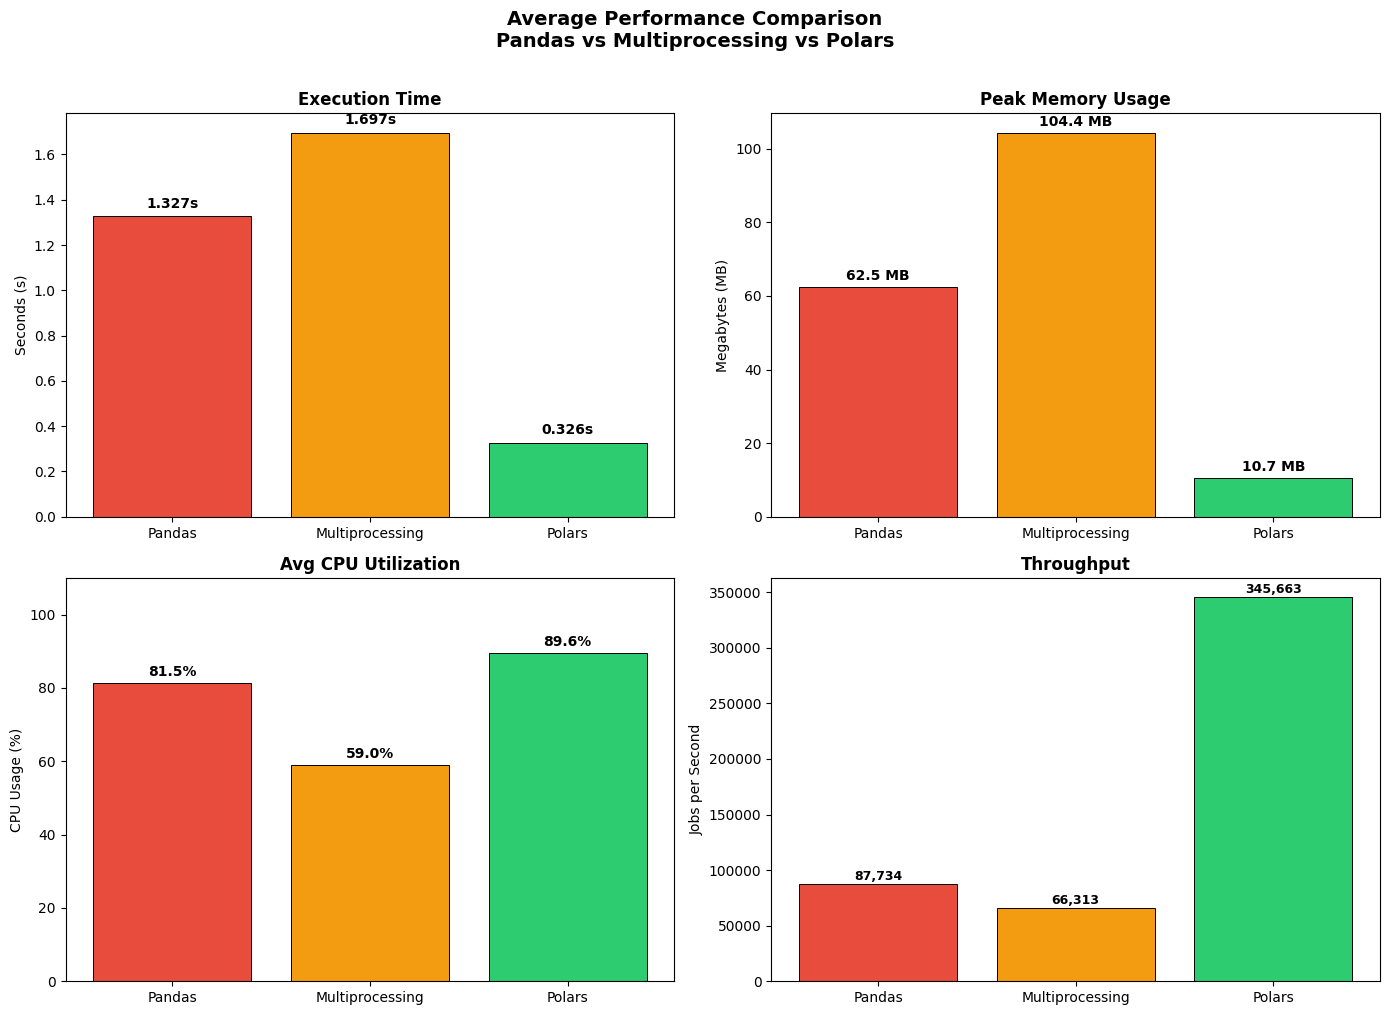

Chart saved as performance_comparison.png


In [ ]:
import matplotlib.pyplot as plt

methods_list = list(avg_results.keys())
colors       = ['#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Average Performance Comparison\nPandas vs Multiprocessing vs Polars',
             fontsize=14, fontweight='bold', y=1.01)

# ── Chart 1: Execution Time ────────────────────────────────
ax = axes[0, 0]
vals = [avg_results[m]['elapsed_time_s'] for m in methods_list]
errs = [std_results[m]['elapsed_time_s'] for m in methods_list]
bars = ax.bar(methods_list, vals, color=colors, edgecolor='black', linewidth=0.7)
ax.set_title('Execution Time', fontweight='bold')
ax.set_ylabel('Seconds (s)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(errs) * 0.1,
            f'{val:.3f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Chart 2: Memory Usage ─────────────────────────────────
ax = axes[0, 1]
vals = [avg_results[m]['peak_memory_mb'] for m in methods_list]
errs = [std_results[m]['peak_memory_mb'] for m in methods_list]
bars = ax.bar(methods_list, vals, color=colors, edgecolor='black', linewidth=0.7)
ax.set_title('Peak Memory Usage', fontweight='bold')
ax.set_ylabel('Megabytes (MB)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(errs) * 0.1,
            f'{val:.1f} MB', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Chart 3: CPU Utilization ──────────────────────────────
ax = axes[1, 0]
vals = [avg_results[m]['avg_cpu_pct'] for m in methods_list]
errs = [std_results[m]['avg_cpu_pct'] for m in methods_list]
bars = ax.bar(methods_list, vals, color=colors, edgecolor='black', linewidth=0.7)
ax.set_title('Avg CPU Utilization', fontweight='bold')
ax.set_ylabel('CPU Usage (%)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Chart 4: Throughput ──────────────────────────────
ax = axes[1, 1]
vals = [avg_results[m]['throughput_rps'] for m in methods_list]
errs = [std_results[m]['throughput_rps'] for m in methods_list]
bars = ax.bar(methods_list, vals, color=colors, edgecolor='black', linewidth=0.7)
ax.set_title('Throughput', fontweight='bold')
ax.set_ylabel('Jobs per Second')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(errs) * 0.05,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as performance_comparison.png")